**Fundamentos de Data Science**

**Analizando la Satisfacción de Clientes en la Industria Hotelera**

Tu tarea es limpiar y explorar un dataset que contiene información sobre la satisfacción de los clientes en la industria hotelera. Este análisis es crucial para los ejecutivos de la empresa que buscan entender mejor las opiniones y experiencias de sus clientes para mejorar los servicios ofrecidos.


**1. Limpieza de datos con Python:**

1.1. Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.

1.2. Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

1.3. Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘yes’, ‘Yes’, ‘YES’).

1.4. Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.

1.5. Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, una estancia de 1000 noches).


In [84]:
# Importamos pandas para la manipulación y estructuración de los datos.
import pandas as pd

# Importamos numpy para operaciones matemáticas avanzadas si fuesen necesarias.
import numpy as np

# Importamos matplotlib y seaborn para la creación de visualizaciones estadísticas.
import matplotlib.pyplot as plt
import seaborn as sns


In [85]:
# Implementamos control de errores para la carga del archivo.
try:
    df = pd.read_csv("/content/World-happiness-report-2024.csv")
    print("Dataset demanda de reservas de hotel cargado exitosamente.")
except FileNotFoundError:
    print(f"Error crítico: El archivo no se encontró en el directorio.")
    exit()

Dataset demanda de reservas de hotel cargado exitosamente.


In [86]:
# Visualizamos los primeros y ultimos registros para entender la estructura tabular.
print("Primeras filas del DataFrame:")
print(df.head())
print("Últimas filas del DataFrame:")
print(df.tail())

Primeras filas del DataFrame:
  Country name            Regional indicator  Ladder score  upperwhisker  \
0      Finland                Western Europe         7.741         7.815   
1      Denmark                Western Europe         7.583         7.665   
2      Iceland                Western Europe         7.525         7.618   
3       Sweden                Western Europe         7.344         7.422   
4       Israel  Middle East and North Africa         7.341         7.405   

   lowerwhisker  Log GDP per capita  Social support  Healthy life expectancy  \
0         7.667               1.844           1.572                    0.695   
1         7.500               1.908           1.520                    0.699   
2         7.433               1.881           1.617                    0.718   
3         7.267               1.878           1.501                    0.724   
4         7.277               1.803           1.513                    0.740   

   Freedom to make life choices 

In [87]:
# Revisamos los metadatos: cantidad de nulos y tipos de variables originales.
print("\n--- Información Estructural ---")
df.info()


--- Información Estructural ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memor

In [88]:
# Generar estadísticas descriptivas
print("Estadísticas descriptivas del DataFrame:")
print(df.describe())

Estadísticas descriptivas del DataFrame:
       Ladder score  upperwhisker  lowerwhisker  Log GDP per capita  \
count    143.000000    143.000000    143.000000          140.000000   
mean       5.527580      5.641175      5.413972            1.378807   
std        1.170717      1.155008      1.187133            0.425098   
min        1.721000      1.775000      1.667000            0.000000   
25%        4.726000      4.845500      4.606000            1.077750   
50%        5.785000      5.895000      5.674000            1.431500   
75%        6.416000      6.507500      6.319000            1.741500   
max        7.741000      7.815000      7.667000            2.141000   

       Social support  Healthy life expectancy  Freedom to make life choices  \
count      140.000000               140.000000                    140.000000   
mean         1.134329                 0.520886                      0.620621   
std          0.333317                 0.164923                      0.162492   

In [89]:
# Inspeccionar los tipos de datos de las columnas
print("nTipos de datos de las columnas:")
print(df.dtypes)

nTipos de datos de las columnas:
Country name                     object
Regional indicator               object
Ladder score                    float64
upperwhisker                    float64
lowerwhisker                    float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + residual             float64
dtype: object


In [90]:
# Obtenemos un conteo inicial de valores faltantes por columna.
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())


--- Conteo de Valores Nulos ---
Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64


In [91]:
# 1.1. Detección y eliminación de valores duplicados: Asegúrate de que cada registro en el dataset sea único.
cantidad_duplicados = df.duplicated().sum()
print(f"Duplicados encontrados: {cantidad_duplicados}")

# Eliminamos duplicados directamente sobre el DataFrame.
initial_rows = len(df)
df.drop_duplicates(inplace=True)

print(f"Se eliminaron {initial_rows - len(df)} filas duplicadas. Filas restantes: {len(df)}")

Duplicados encontrados: 0
Se eliminaron 0 filas duplicadas. Filas restantes: 143


In [92]:
# 1.2. Verificación y ajuste de tipos de datos: Asegúrate de que todas las columnas coincidan con los tipos de datos indicados en el diccionario de datos.

print("Tipos de datos actuales")
print(df.dtypes)

# Convertir columnas categóricas a string
df['Country name'] = df['Country name'].astype(str)
df['Regional indicator'] = df['Regional indicator'].astype(str)

# Convertir columnas numéricas a float
columnas_float = [
    'Ladder score',
    'upperwhisker',
    'lowerwhisker',
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption',
    'Dystopia + residual'
]

for col in columnas_float:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Verificar nuevamente
print("\nTipos de datos corregidos")
print(df.dtypes)

Tipos de datos actuales
Country name                     object
Regional indicator               object
Ladder score                    float64
upperwhisker                    float64
lowerwhisker                    float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + residual             float64
dtype: object

Tipos de datos corregidos
Country name                     object
Regional indicator               object
Ladder score                    float64
upperwhisker                    float64
lowerwhisker                    float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + resi

In [93]:
# 1.3. Consistencia en valores categóricos: Identifica y corrige cualquier inconsistencia en los valores categóricos (por ejemplo, ‘yes’, ‘Yes’, ‘YES’).
# Estandarizamos los Regional indicator :
# .str.strip() elimina espacios en blanco al inicio o final.
# .str.title() asegura que la primera letra sea mayúscula (Capitalize).
df['Regional indicator'] = df['Regional indicator'].str.strip().str.title()

# Visualizamos los Regional indicator para confirmar la homogeneidad.
print("Regional indicator tras estandarización:\n", df['Regional indicator'].unique())

Regional indicator tras estandarización:
 ['Western Europe' 'Middle East And North Africa' 'North America And Anz'
 'Latin America And Caribbean' 'Central And Eastern Europe'
 'Southeast Asia' 'East Asia' 'Commonwealth Of Independent States'
 'Sub-Saharan Africa' 'South Asia']


In [94]:
# 1.3. Estandarizamos los Country name :
# .str.strip() elimina espacios en blanco al inicio o final.
# .str.title() asegura que la primera letra sea mayúscula (Capitalize).
df['Country name'] = df['Country name'].str.strip().str.title()

# Visualizamos los Country name para confirmar la homogeneidad.
print("Country name tras estandarización:\n", df['Country name'].unique())

Country name tras estandarización:
 ['Finland' 'Denmark' 'Iceland' 'Sweden' 'Israel' 'Netherlands' 'Norway'
 'Luxembourg' 'Switzerland' 'Australia' 'New Zealand' 'Costa Rica'
 'Kuwait' 'Austria' 'Canada' 'Belgium' 'Ireland' 'Czechia' 'Lithuania'
 'United Kingdom' 'Slovenia' 'United Arab Emirates' 'United States'
 'Germany' 'Mexico' 'Uruguay' 'France' 'Saudi Arabia' 'Kosovo' 'Singapore'
 'Taiwan Province Of China' 'Romania' 'El Salvador' 'Estonia' 'Poland'
 'Spain' 'Serbia' 'Chile' 'Panama' 'Malta' 'Italy' 'Guatemala' 'Nicaragua'
 'Brazil' 'Slovakia' 'Latvia' 'Uzbekistan' 'Argentina' 'Kazakhstan'
 'Cyprus' 'Japan' 'South Korea' 'Philippines' 'Vietnam' 'Portugal'
 'Hungary' 'Paraguay' 'Thailand' 'Malaysia' 'China' 'Honduras' 'Bahrain'
 'Croatia' 'Greece' 'Bosnia And Herzegovina' 'Libya' 'Jamaica' 'Peru'
 'Dominican Republic' 'Mauritius' 'Moldova' 'Russia' 'Bolivia' 'Ecuador'
 'Kyrgyzstan' 'Montenegro' 'Mongolia' 'Colombia' 'Venezuela' 'Indonesia'
 'Bulgaria' 'Armenia' 'South Africa' 'Nor

In [95]:
# 1.4. Manejo de valores faltantes: Identifica y maneja cualquier valor faltante en el dataset. Rellena los valores faltantes con un marcador adecuado para el tipo de dato.
# Calcular la cantidad de valores nulos por cada columna en el DataFrame df
nulos = df.isnull().sum()
# Filtrar solo las columnas que tienen al menos un valor nulo
# y ordenarlas de mayor a menor cantidad de nulos
nulos = nulos[nulos > 0].sort_values(ascending=False)
# Imprimir la cantidad de valores nulos por columna (solo las que tienen nulos)
print(nulos)

Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64


In [96]:
# Rellenar valores nulos usando
# el mismo país como referencia
columnas = [
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption',
    'Dystopia + residual'
]
# Recorrer columnas
for col in columnas:
    df[col] = df.groupby(
        'Country name'
    )[col].transform(
        lambda x: x.fillna(x.mean())
    )
# Verificar nulos restantes
print(df[columnas].isnull().sum())

Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64


In [97]:
# Mostrar filas que tienen al menos un valor nulo
filas_nulas = df[
    df.isnull().any(axis=1)
]
print(filas_nulas)

           Country name                  Regional indicator  Ladder score  \
61              Bahrain        Middle East And North Africa         5.959   
87           Tajikistan  Commonwealth Of Independent States         5.281   
102  State Of Palestine        Middle East And North Africa         4.879   

     upperwhisker  lowerwhisker  Log GDP per capita  Social support  \
61          6.153         5.766                 NaN             NaN   
87          5.361         5.201                 NaN             NaN   
102         5.006         4.753                 NaN             NaN   

     Healthy life expectancy  Freedom to make life choices  Generosity  \
61                       NaN                           NaN         NaN   
87                       NaN                           NaN         NaN   
102                      NaN                           NaN         NaN   

     Perceptions of corruption  Dystopia + residual  
61                         NaN                  NaN  
8

In [102]:
# rellenar nulos con promedio por región.
for col in columnas:

    df[col] = df.groupby(
        'Regional indicator'
    )[col].transform(
        lambda x: x.fillna(x.mean())
    )

In [103]:
print(df.isnull().sum())

Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
Dystopia + residual             0
dtype: int64


In [104]:
# 1.5. Detección de datos anómalos: Identifica y corrige cualquier punto de dato inapropiado o inusual (por ejemplo, una estancia de 1000 noches).
# Revisar valores muy altos

print(
    df[df['Healthy life expectancy'] > 100]
)

print(
    df[df['Ladder score'] > 10]
)

print(
    df[df['Log GDP per capita'] < 0]
)

Empty DataFrame
Columns: [Country name, Regional indicator, Ladder score, upperwhisker, lowerwhisker, Log GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption, Dystopia + residual]
Index: []
Empty DataFrame
Columns: [Country name, Regional indicator, Ladder score, upperwhisker, lowerwhisker, Log GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption, Dystopia + residual]
Index: []
Empty DataFrame
Columns: [Country name, Regional indicator, Ladder score, upperwhisker, lowerwhisker, Log GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, Perceptions of corruption, Dystopia + residual]
Index: []


In [122]:
# Buscar ceros en variables numéricas
# Seleccionar variables numéricas
variables_numericas = [
    'Ladder score',
    'Log GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption',
    'Dystopia + residual'
]
for col in variables_numericas:
    cantidad_ceros = (df[col] == 0).sum()

    print(f"{col}: {cantidad_ceros} valores en 0")

Ladder score: 0 valores en 0
Log GDP per capita: 1 valores en 0
Social support: 1 valores en 0
Healthy life expectancy: 1 valores en 0
Freedom to make life choices: 1 valores en 0
Generosity: 1 valores en 0
Perceptions of corruption: 1 valores en 0
Dystopia + residual: 0 valores en 0


Durante la etapa de limpieza de datos, primero se revisó si existían registros duplicados y se comprobó que las 143 filas del dataset eran únicas. Luego, se verificaron los tipos de datos de cada columna para asegurar que las variables numéricas y categóricas estuvieran correctamente definidas.

También se realizó una estandarización de los valores categóricos, corrigiendo diferencias en formatos de escritura y eliminando espacios innecesarios para mantener una mayor consistencia en la información.

En cuanto a los valores faltantes, se detectaron 3 filas con datos nulos en varias variables numéricas. Como no fue posible completar esos valores utilizando información del mismo país, se optó por rellenarlos con el promedio correspondiente a su región, permitiendo conservar los registros sin afectar significativamente el análisis.

Finalmente, se revisó la existencia de posibles datos anómalos o fuera de rango y no se encontraron valores inconsistentes, por lo que el dataset quedó limpio y listo para el análisis exploratorio.

Nota: Se identificaron algunos valores iguales a 0 en variables como PIB per cápita, apoyo social y expectativa de vida.
Debido a que corresponden a registros reales del dataset original y representan contextos socioeconómicos extremos, se decidió mantenerlos.



**2. Exploración de datos con Python:**

2.1. Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

2.2. Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas. Cada visualización debe incluir una breve interpretación dentro del archivo de código.

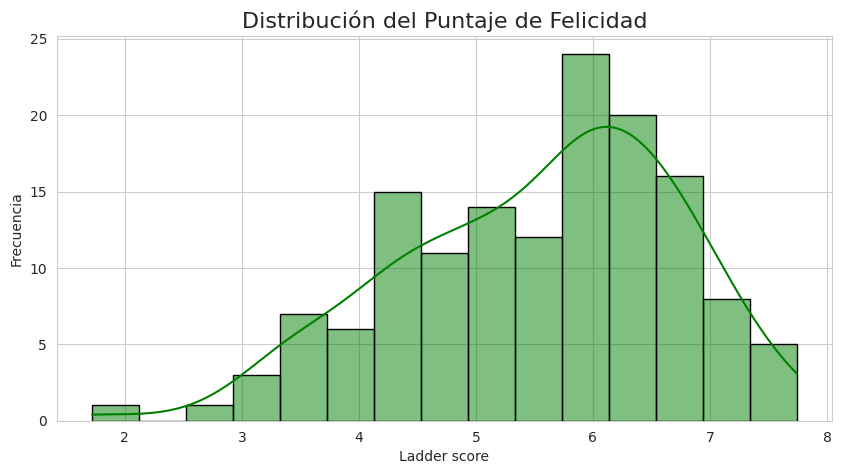

La mayoría de los países presenta niveles de felicidad intermedios, concentrándose aproximadamente entre 4 y 7 puntos.
Se observan pocos países con niveles extremadamente bajos o altos.


In [111]:
# 2.1. Visualizaciones exploratorias univariadas: Crea dos tipos diferentes de visualizaciones univariadas.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.
# Estilo general
sns.set_style("whitegrid")
# Histograma - Ladder score (Nivel de felicidad)
plt.figure(figsize=(10,5))
sns.histplot(
    df['Ladder score'],
    bins=15,
    kde=True,
    color='green',
    edgecolor='black'
)
plt.title(
    'Distribución del Puntaje de Felicidad',
    fontsize=16
)
plt.xlabel('Ladder score')
plt.ylabel('Frecuencia')
plt.show()

print('La mayoría de los países presenta niveles de felicidad intermedios, concentrándose aproximadamente entre 4 y 7 puntos.')
print('Se observan pocos países con niveles extremadamente bajos o altos.')

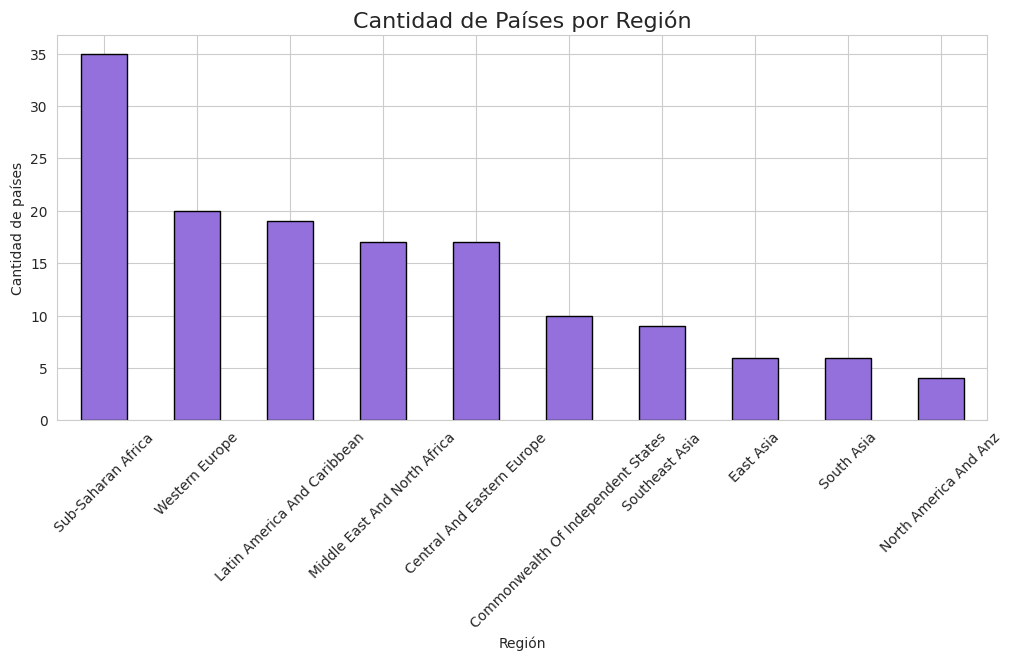

Algunas regiones concentran una mayor cantidad de países dentro del dataset, destacando especialmente Europa y África,
mientras que otras regiones poseen menor representación.


In [113]:
# Gráfico de barras - Regiones más frecuentes
plt.figure(figsize=(12,5))
df['Regional indicator'].value_counts().plot(
    kind='bar',
    color='mediumpurple',
    edgecolor='black'
)
plt.title(
    'Cantidad de Países por Región',
    fontsize=16
)
plt.xlabel('Región')
plt.ylabel('Cantidad de países')
plt.xticks(rotation=45)
plt.show()
print('Algunas regiones concentran una mayor cantidad de países dentro del dataset, destacando especialmente Europa y África,')
print('mientras que otras regiones poseen menor representación.')

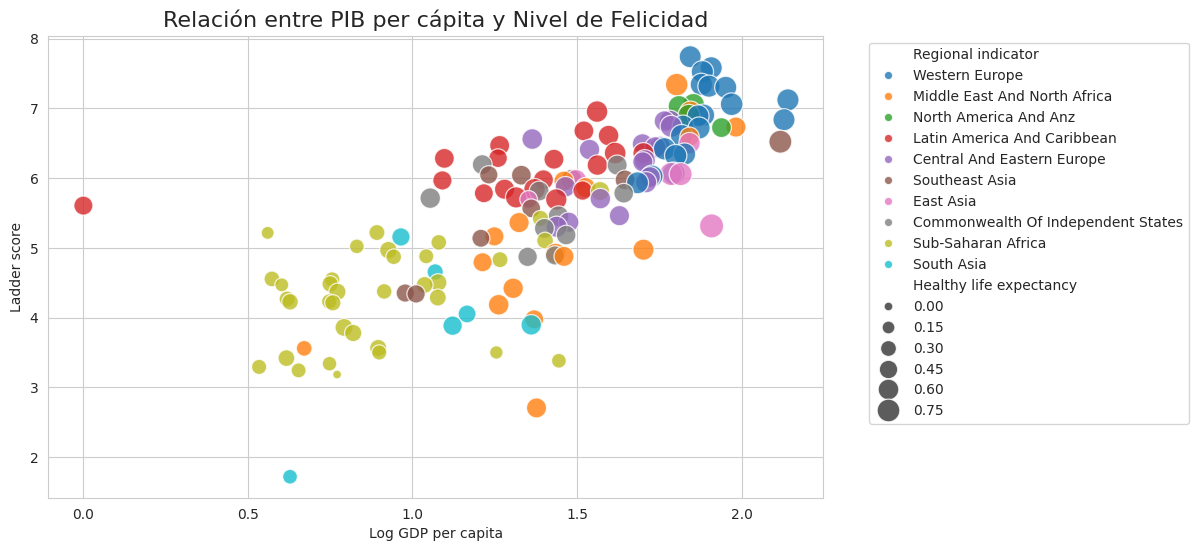

Se observa una relación positiva entre el PIB per cápita y el nivel de felicidad.
En general, los países con mayores ingresos presentan mejores puntajes de felicidad y mayor expectativa de vida saludable.


In [116]:
# 2.2. Visualizaciones exploratorias multivariadas: Crea dos tipos diferentes de visualizaciones multivariadas.
# Cada visualización debe incluir una breve interpretación dentro del archivo de código.
# 2.2.1. Relación entre PIB y Felicidad
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Log GDP per capita',
    y='Ladder score',
    hue='Regional indicator',
    size='Healthy life expectancy',
    palette='tab10',
    sizes=(40, 300),
    alpha=0.8
)
plt.title(
    'Relación entre PIB per cápita y Nivel de Felicidad',
    fontsize=16
)
plt.xlabel('Log GDP per capita')
plt.ylabel('Ladder score')
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.show()
print('Se observa una relación positiva entre el PIB per cápita y el nivel de felicidad.')
print('En general, los países con mayores ingresos presentan mejores puntajes de felicidad y mayor expectativa de vida saludable.')


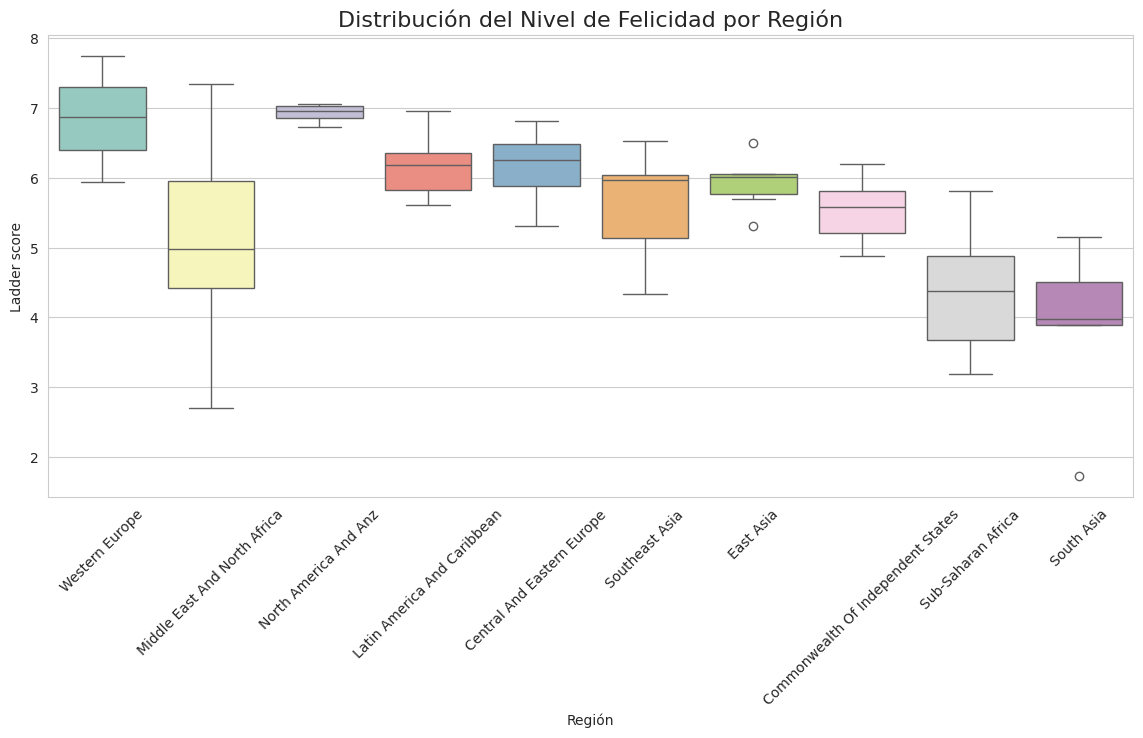

Existen diferencias claras en los niveles de felicidad entre regiones.
Algunas regiones presentan medianas más altas y menor dispersión, mientras que otras muestran mayor variabilidad entre países.


In [118]:
# 2.2.2. Boxplot comparativo por región
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df,
    x='Regional indicator',
    y='Ladder score',
    hue='Regional indicator',
    palette='Set3',
    legend=False
)
plt.title(
    'Distribución del Nivel de Felicidad por Región',
    fontsize=16
)
plt.xlabel('Región')
plt.ylabel('Ladder score')
plt.xticks(rotation=45)
plt.show()
print('Existen diferencias claras en los niveles de felicidad entre regiones.')
print('Algunas regiones presentan medianas más altas y menor dispersión, mientras que otras muestran mayor variabilidad entre países.')


Los gráficos permiten identificar patrones importantes relacionados con el nivel de felicidad de los países y los factores que lo influyen.
La distribución del Ladder score muestra que la mayoría de los países se concentra entre valores de 5 y 7, indicando niveles de felicidad moderados a altos. Además, la región con mayor cantidad de países en el dataset es Sub-Saharan Africa, mientras que regiones como North America and ANZ poseen menos países, pero presentan algunos de los niveles de felicidad más altos.

Por otra parte, el gráfico de dispersión evidencia una relación positiva entre el PIB per cápita y el nivel de felicidad en general, los países con mayores ingresos tienden a registrar mejores puntajes de felicidad y mayor expectativa de vida saludable.

Finalmente, el boxplot muestra diferencias claras entre regiones, destacando que Western Europe y North America and ANZ presentan medianas de felicidad más elevadas y menor dispersión, mientras que regiones como Sub-Saharan Africa y South Asia muestran niveles más bajos y una mayor variabilidad en sus resultados.


**3. Análisis adicional:**

3.1. Estadísticas descriptivas: Proporciona un resumen estadístico del dataset, incluyendo medidas de tendencia central y dispersión para las variables numéricas.

3.2. Identificación de tendencias: Analiza y discute cualquier tendencia notable que observes en los datos, apoyándote en las visualizaciones y estadísticas descriptivas.


In [125]:
# 3.1. Resumen estadístico general
print("Resumen estadístico:")
print(df[variables_numericas].describe())

Resumen estadístico:
       Ladder score  Log GDP per capita  Social support  \
count    143.000000          143.000000      143.000000   
mean       5.527580            1.380105        1.134468   
std        1.170717            0.420698        0.329985   
min        1.721000            0.000000        0.000000   
25%        4.726000            1.079000        0.924500   
50%        5.785000            1.433000        1.236000   
75%        6.416000            1.733000        1.377000   
max        7.741000            2.141000        1.617000   

       Healthy life expectancy  Freedom to make life choices  Generosity  \
count               143.000000                    143.000000  143.000000   
mean                  0.521496                      0.619383    0.145714   
std                   0.163226                      0.161595    0.072802   
min                   0.000000                      0.000000    0.000000   
25%                   0.400000                      0.523000    0.0

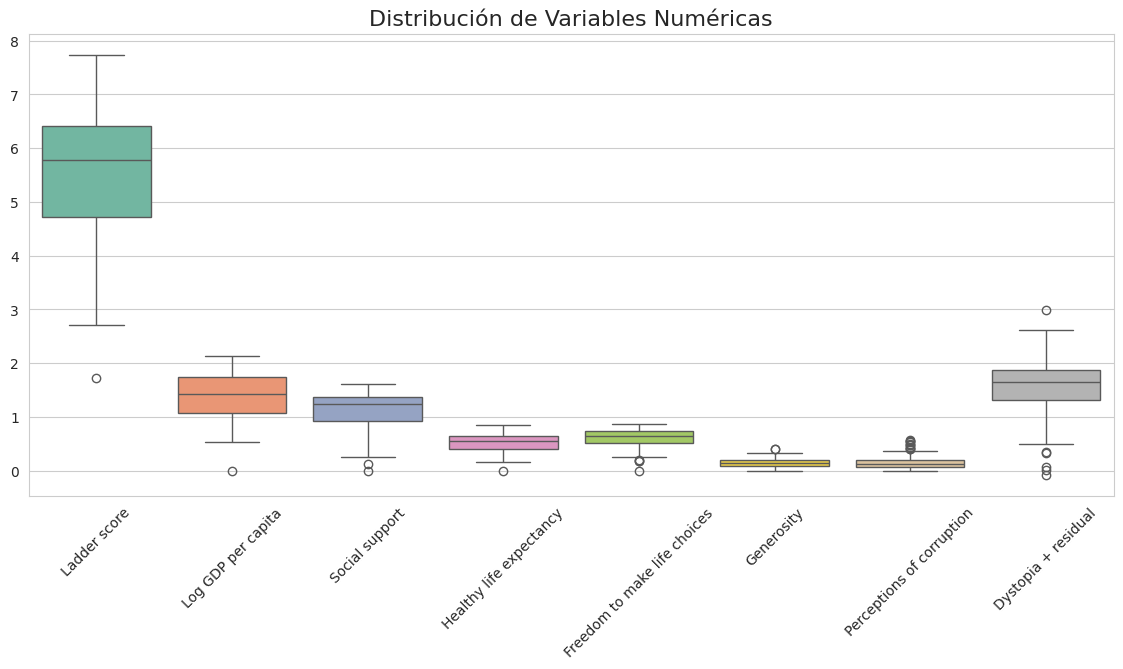

In [129]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df[variables_numericas],
    palette='Set2'
)
plt.title(
    'Distribución de Variables Numéricas',
    fontsize=16
)
plt.xticks(rotation=45)
plt.show()

3.2. A partir de las estadísticas descriptivas y las visualizaciones realizadas, se observan varias tendencias importantes en el dataset.

El puntaje de felicidad presenta una media de 5.53, con valores que varían entre 1.72 y 7.74, lo que evidencia diferencias significativas en los niveles de bienestar entre los países analizados.

Se identifica una tendencia positiva entre el PIB per cápita y el nivel de felicidad, ya que los países con mayores ingresos tienden a registrar puntajes de felicidad más altos.

También se observa que variables como el apoyo social y la expectativa de vida saludable presentan valores más elevados en los países con mayores niveles de felicidad, sugiriendo que las condiciones sociales y de salud influyen considerablemente en el bienestar de la población.

Además, la libertad para tomar decisiones muestra una tendencia moderadamente alta en países con mejores evaluaciones de felicidad.

Por otro lado, variables como Generosity y Perceptions of corruption presentan una mayor dispersión y variabilidad, indicando que su relación con la felicidad no es tan uniforme entre regiones.

Finalmente, las visualizaciones por región muestran que regiones como Western Europe y North America and ANZ concentran los niveles más altos de felicidad, mientras que Sub-Saharan Africa y South Asia presentan puntajes más bajos y una mayor variabilidad.


**Nota:** Uso de recursos externos. Durante el desarrollo de este análisis se utilizaron recursos de apoyo como apuntes de clases, trabajos Core, Examen tipo realizado por Profesores, (examen 1, examen 2 y examenes tipos) documentación oficial de Pandas, Matplotlib, Scikit-learn y consultas complementarias en ChatGPT para resolver dudas, depurar errores y mejorar la comprensión del código utilizado.

Referencias:

https://pandas.pydata.org/docs/

https://matplotlib.org/stable/index.html

https://scikit-learn.org/stable/

https://chat.openai.com/

https://seaborn.pydata.org/



